In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

**Motivation & objective**

Imbalanced datasets are ubiquitous in real-world machine learning tasks, where one class significantly outnumbers the other(s). While this scenario is common, it poses significant challenges for traditional machine learning algorithms, which tend to be biased towards the majority class and perform poorly on minority classes. In this lab, we will explore three techniques to address the imbalance issue: subsampling, oversampling, and Synthetic Minority Over-sampling Technique (SMOTE). By implementing these techniques, we aim to improve the model's performance on imbalanced datasets and make our predictions more reliable.

---

**Importing the Dataset**:

Let's start by importing the Credit Card Fraud Detection dataset, a real-world example of an imbalanced dataset where fraudulent transactions are the minority class.

*Download the dataset here!!*

https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [3]:
df = pd.read_csv("../data/creditcard.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
# check the first rows of this dataset

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# this is extremely imbalanced

df['Class'].value_counts()

# but also expected, since frauds are a mere fraction of all transactions

Class
0    284315
1       492
Name: count, dtype: int64

**Train/Test Split and Baseline Model**

Before applying any techniques to handle the imbalance, let's establish a baseline model. 

We'll perform a simple train/test split and train a RandomForest classifier on the training set, evaluating its performance on the test set.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [8]:
# Splitting the data into train and test sets

X,y = df.drop(columns=['Class']), df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

As we can see below, both splits are also heavily imbalanced

In [9]:
y_train.value_counts()

Class
0    227451
1       394
Name: count, dtype: int64

In [10]:
y_test.value_counts()

Class
0    56864
1       98
Name: count, dtype: int64

Training a RandomForest classifier

In [11]:
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Evaluating it on the test set

In [12]:
y_pred = rf_classifier.predict(X_test)

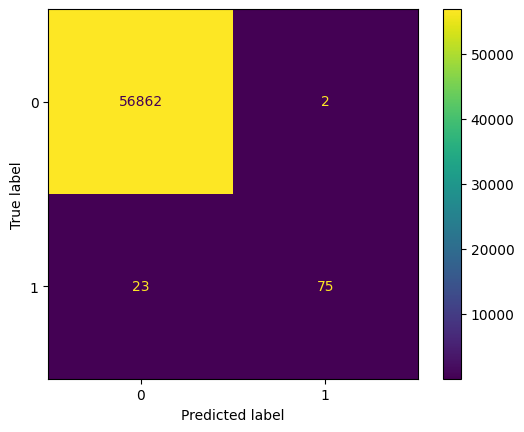

In [13]:
cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])

cm_display.plot()
plt.show() 

In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Baseline Model Performance:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Baseline Model Performance:
Accuracy: 0.9995611109160493
Precision: 0.974025974025974
Recall: 0.7653061224489796


---

**Subsampling**

Subsampling involves reducing the number of samples in the majority class to balance the dataset. 

*However, it's essential to perform subsampling only on the training set to avoid information loss in the test set.* 

This point actually stands for any other sampling method aswell. We want our test set to represent reality, and we therefore, as usual, can't alter it.

In [15]:
# install the imblearn-package

!pip install imblearn


   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]



In [16]:
from imblearn.under_sampling import RandomUnderSampler

# Subsampling the majority class in the training set

undersampler = RandomUnderSampler(random_state=42)

X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)

In [17]:
# note that this is now balanced!

y_train_resampled.value_counts()

Class
0    394
1    394
Name: count, dtype: int64

Training a RandomForest classifier

In [18]:
# Training a new RandomForest classifier on the resampled data

rf_classifier_resampled = RandomForestClassifier(random_state=42)
rf_classifier_resampled.fit(X_train_resampled, y_train_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Evaluate it on the test set

In [19]:
y_pred_resampled = rf_classifier_resampled.predict(X_test)

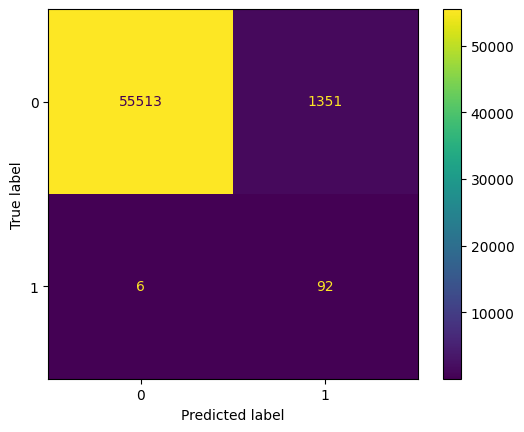

In [20]:
cm = confusion_matrix(y_true=y_test, y_pred=y_pred_resampled)

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])

cm_display.plot()
plt.show() 

In [21]:
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
precision_resampled = precision_score(y_test, y_pred_resampled)
recall_resampled = recall_score(y_test, y_pred_resampled)

print("Subsampling Model Performance:")
print("Accuracy:", accuracy_resampled)
print("Precision:", precision_resampled)
print("Recall:", recall_resampled)

Subsampling Model Performance:
Accuracy: 0.9761771005231558
Precision: 0.06375606375606375
Recall: 0.9387755102040817


---

**Oversampling**

Oversampling involves increasing the number of samples in the minority class to balance the dataset.

In [22]:
from imblearn.over_sampling import RandomOverSampler

# Oversampling the minority class in the training set

oversampler = RandomOverSampler(random_state=42)
X_train_oversampled, y_train_oversampled = oversampler.fit_resample(X_train, y_train)

In [23]:
# notice that this is now balanced!

In [24]:
y_train_oversampled.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

Train a RandomForest Classifier

In [25]:
rf_classifier_oversampled = RandomForestClassifier(random_state=42)
rf_classifier_oversampled.fit(X_train_oversampled, y_train_oversampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Evaluate it on the test set

In [26]:
y_pred_oversampled = rf_classifier_oversampled.predict(X_test)

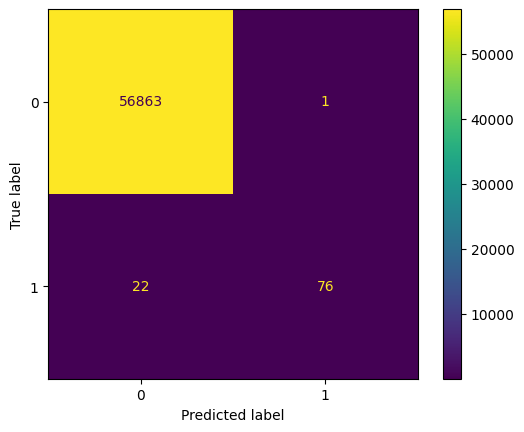

In [27]:
cm = confusion_matrix(y_true=y_test, y_pred=y_pred_oversampled)

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])

cm_display.plot()
plt.show() 

In [28]:
accuracy_oversampled = accuracy_score(y_test, y_pred_oversampled)
precision_oversampled = precision_score(y_test, y_pred_oversampled)
recall_oversampled = recall_score(y_test, y_pred_oversampled)

print("\nOversampling Model Performance:")
print("Accuracy:", accuracy_oversampled)
print("Precision:", precision_oversampled)
print("Recall:", recall_oversampled)


Oversampling Model Performance:
Accuracy: 0.9995962220427653
Precision: 0.987012987012987
Recall: 0.7755102040816326


---

**SMOTE (Synthetic Minority Over-sampling Technique)**

SMOTE generates synthetic samples for the minority class to balance the dataset.

In [29]:
from imblearn.over_sampling import SMOTE

# Applying SMOTE to the training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [30]:
# note that this is now balanced

y_train_smote.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

Train a RandomForest classifier

In [31]:
rf_classifier_smote = RandomForestClassifier(random_state=42)
rf_classifier_smote.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Evaluate it on the test set

In [32]:
y_pred_smote = rf_classifier_smote.predict(X_test)

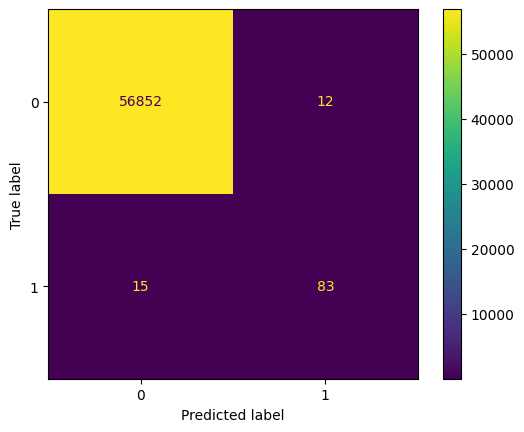

In [33]:
cm = confusion_matrix(y_true=y_test, y_pred=y_pred_smote)

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])

cm_display.plot()
plt.show() 

In [34]:
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)

print("\nSMOTE Model Performance:")
print("Accuracy:", accuracy_smote)
print("Precision:", precision_smote)
print("Recall:", recall_smote)


SMOTE Model Performance:
Accuracy: 0.9995259997893332
Precision: 0.8736842105263158
Recall: 0.8469387755102041


---

## Challenges 

**Task 1**

Understand everything we've done above.

**Task 2**

Recall that we in the binary classification case, predict the class which has the biggest probability. 

Since there are only 2 classes, we predict the one which has 0.5 (by default).

However, oftentimes it's worth altering this prediction threshold/cutoff to something else. This way, we can also affect our accuracy/precision/recall.

Run the code below to see how to do this.

In [35]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)   

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
# get all prediction probabilities

prediction_probabilities = rf.predict_proba(X_test)

# extract only the probabilities for the positive class

prediction_for_positive_class = prediction_probabilities[:, 1]

In [37]:
# Define the range of threshold values

threshold_values = np.linspace(0.2,0.8,25)

threshold_values

array([0.2  , 0.225, 0.25 , 0.275, 0.3  , 0.325, 0.35 , 0.375, 0.4  ,
       0.425, 0.45 , 0.475, 0.5  , 0.525, 0.55 , 0.575, 0.6  , 0.625,
       0.65 , 0.675, 0.7  , 0.725, 0.75 , 0.775, 0.8  ])

The above threshold values are what we will loop over below. Specifically, each threshold represents the required probability for class 1 for us to predict it.

In [38]:
# Loop through each threshold value
for threshold in threshold_values:

    # Convert predicted probabilities to binary predictions based on the current threshold
    y_pred = (prediction_for_positive_class >= threshold).astype(int)
    
    accuracy = round(accuracy_score(y_test, y_pred),4)
    precision = round(precision_score(y_test, y_pred),4)
    recall = round(recall_score(y_test, y_pred),4)
    
    # Print the metrics for the current threshold
    print(f'Threshold : {round(threshold,2)}')
    print(f'Accuracy  : {accuracy}')
    print(f'Precision : {precision}')
    print(f'Recall    : {recall}', end='\n\n')

Threshold : 0.2
Accuracy  : 0.9995
Precision : 0.8469
Recall    : 0.8469

Threshold : 0.22
Accuracy  : 0.9995
Precision : 0.8557
Recall    : 0.8469

Threshold : 0.25
Accuracy  : 0.9995
Precision : 0.8646
Recall    : 0.8469

Threshold : 0.28
Accuracy  : 0.9995
Precision : 0.8737
Recall    : 0.8469

Threshold : 0.3
Accuracy  : 0.9995
Precision : 0.8817
Recall    : 0.8367

Threshold : 0.33
Accuracy  : 0.9996
Precision : 0.9111
Recall    : 0.8367

Threshold : 0.35
Accuracy  : 0.9996
Precision : 0.9205
Recall    : 0.8265

Threshold : 0.38
Accuracy  : 0.9996
Precision : 0.9419
Recall    : 0.8265

Threshold : 0.4
Accuracy  : 0.9996
Precision : 0.9529
Recall    : 0.8265

Threshold : 0.43
Accuracy  : 0.9996
Precision : 0.9524
Recall    : 0.8163

Threshold : 0.45
Accuracy  : 0.9996
Precision : 0.963
Recall    : 0.7959

Threshold : 0.48
Accuracy  : 0.9996
Precision : 0.963
Recall    : 0.7959

Threshold : 0.5
Accuracy  : 0.9996
Precision : 0.975
Recall    : 0.7959

Threshold : 0.53
Accuracy  : 0.9


---

## Further exercises

These exercises build on the work above and focus on **why** imbalanced classification needs different evaluation habits.  



### Exercise 0 — Helper imports and utility function
Run the cell below before starting the exercises.


In [42]:

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt


def evaluate_model(name, y_true, y_pred, y_score=None):
    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        metrics['average_precision'] = average_precision_score(y_true, y_score)
    return metrics



### Exercise 1 - The accuracy trap
Create a dummy model that ALWAYS predicts every transaction as the majority class (`0`, i.e. non-fraud). Compare it with the original Random Forest model trained above using the metrics:

- accuracy
- precision
- recall
- confusion matrix

**Questions**
1. Why can the dummy model still achieve very high accuracy?
2. Why is it still useless in practice?
3. Which metric exposes the problem most clearly?


In [45]:

# YOUR CODE HERE
# 1) Create a dummy classifier that always predicts the majority class
# 2) Compare it with the original random forest from above
# 3) Print metrics and confusion matrices for both (hint: use the evaluate_model function)



**SOLUTION — remove before distributing**


In [43]:

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_pred_rf = rf_classifier.predict(X_test)

print('Dummy confusion matrix:')
print(confusion_matrix(y_test, y_pred_dummy))
print()
print('Random Forest confusion matrix:')
print(confusion_matrix(y_test, y_pred_rf))
print()

comparison = pd.DataFrame([
    evaluate_model('Dummy majority-class', y_test, y_pred_dummy),
    evaluate_model('Random Forest baseline', y_test, y_pred_rf, rf_classifier.predict_proba(X_test)[:,1])
])
comparison


Dummy confusion matrix:
[[56864     0]
 [   98     0]]

Random Forest confusion matrix:
[[56862     2]
 [   23    75]]



,model,accuracy,precision,recall,average_precision
0,Dummy majority-class,0.998280,0.000000,0.000000,NaN
1,Random Forest baseline,0.999561,0.974026,0.765306,0.8633



### Exercise 2 - Thresholds with a business cost

Missclassifying transactions can have real world consequences. Our fraud team says:

- each **false negative** (missed fraud) costs **500 euro**
- each **false positive** (flagging a legitimate payment) costs **5 euro**

Using baseline Random Forest probabilities:
1. test different thresholds from `0.01` to `0.90`
2. compute the confusion matrix at each threshold
3. Also compute the total expected cost for those thresholds
4. identify the threshold you would recommend

In [ ]:

# YOUR CODE HERE
# Hint: use rf_classifier.predict_proba(X_test)[:, 1]
# Define a cost function based on FP and FN



**SOLUTION — remove before distributing**


In [46]:

probs_baseline = rf_classifier.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.01, 0.90, 60)
rows = []

for threshold in thresholds:
    y_pred_threshold = (probs_baseline >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    total_cost = (fn * 500) + (fp * 5)
    rows.append({
        'threshold': round(float(threshold), 3),
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'precision': precision_score(y_test, y_pred_threshold, zero_division=0),
        'recall': recall_score(y_test, y_pred_threshold, zero_division=0),
        'cost': total_cost
    })

cost_df = pd.DataFrame(rows).sort_values('cost')
cost_df.head(10)


,threshold,tn,fp,fn,tp,precision,recall,cost
1,0.025,56712,152,11,87,0.364017,0.887755,6260
2,0.040,56804,60,13,85,0.586207,0.867347,6800
9,0.146,56845,19,14,84,0.815534,0.857143,7095
8,0.131,56844,20,14,84,0.807692,0.857143,7100
7,0.116,56842,22,14,84,0.792453,0.857143,7110
6,0.101,56838,26,14,84,0.763636,0.857143,7130
5,0.085,56830,34,14,84,0.711864,0.857143,7170
4,0.070,56826,38,14,84,0.688525,0.857143,7190
3,0.055,56815,49,14,84,0.631579,0.857143,7245
20,0.312,56853,11,15,83,0.882979,0.846939,7555


In [47]:

best_row = cost_df.iloc[0]
print('Recommended threshold:', best_row['threshold'])
print(best_row)


Recommended threshold: 0.025
threshold        0.025000
tn           56712.000000
fp             152.000000
fn              11.000000
tp              87.000000
precision        0.364017
recall           0.887755
cost          6260.000000
Name: 1, dtype: float64



### Exercise 3 - Compare data balancing with class weighting
Resampling changes the training data. Another option is to leave the data as-is but tell the model to care more about the minority class.

Train and compare the following:

- baseline Random Forest
- `RandomForestClassifier(class_weight='balanced')`
- random undersampling + Random Forest
- random oversampling + Random Forest
- SMOTE + Random Forest

Compare them using:

- precision
- recall
- F1
- average precision (PR-AUC summary)

*Remember that you've already trained most (but not all) of the models above, and can reuse them*

**Question:** Which approach would you deploy if your goal is to catch more fraud while still keeping false alarms manageable?


In [ ]:

# YOUR CODE HERE
# Train a class-weighted random forest and compare all models in one table



**SOLUTION — remove before distributing**


In [48]:

rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_balanced.fit(X_train, y_train)

model_rows = []

models = [
    ('Baseline RF', rf_classifier, X_test),
    ('Class-weighted RF', rf_balanced, X_test),
    ('Undersampled RF', rf_classifier_resampled, X_test),
    ('Oversampled RF', rf_classifier_oversampled, X_test),
    ('SMOTE RF', rf_classifier_smote, X_test),
]

for name, model, features in models:
    y_pred_model = model.predict(features)
    y_score_model = model.predict_proba(features)[:, 1]
    model_rows.append(evaluate_model(name, y_test, y_pred_model, y_score_model))

comparison_df = pd.DataFrame(model_rows).sort_values(['recall', 'precision'], ascending=False)
comparison_df


,model,accuracy,precision,recall,average_precision
2,Undersampled RF,0.976177,0.063756,0.938776,0.751357
4,SMOTE RF,0.999526,0.873684,0.846939,0.872185
3,Oversampled RF,0.999596,0.987013,0.775510,0.879959
0,Baseline RF,0.999561,0.974026,0.765306,0.863300
1,Class-weighted RF,0.999561,0.986667,0.755102,0.880264



### Exercise 4 - Spot the leakage bug
Read the code below.

```python
smote = SMOTE(random_state=42)
X_smote_all, y_smote_all = smote.fit_resample(X, y)
X_train_bad, X_test_bad, y_train_bad, y_test_bad = train_test_split(
    X_smote_all, y_smote_all, test_size=0.3, random_state=42
)
rf_bad = RandomForestClassifier(random_state=42)
rf_bad.fit(X_train_bad, y_train_bad)
```

**Tasks**
1. Explain why this evaluation is misleading.
2. Rewrite the workflow in the correct order.
3. Briefly describe what kind of information leaks into the test set.


In [ ]:

# YOUR ANSWER HERE



**SOLUTION — remove before distributing**


In [ ]:

print('Why it is wrong: SMOTE was applied before the train/test split.')
print('That means synthetic minority examples in the train set can be created using information from points that later end up in the test set.')
print('The model is therefore evaluated on a test set that is no longer truly unseen.')
print()
print('Correct workflow:')
print('1. Split into train and test sets first.')
print('2. Apply SMOTE only on the training set.')
print('3. Train the model on the resampled training set.')
print('4. Evaluate on the untouched test set.')



### Exercise 5 - Reflection
Answer in 3–5 sentences.

- Why is accuracy especially dangerous as the main metric in imbalanced classification?
- In which application would you care even more about recall than in fraud detection?
- In which application might precision matter more?
